### Demoblatt - SuS
--- 



# `Decision Tree`


Bei **``Decision Trees``** erfolgt die Klassifikation von Daten auf Grund des Informationsgehalts mehrerer Features.<br>


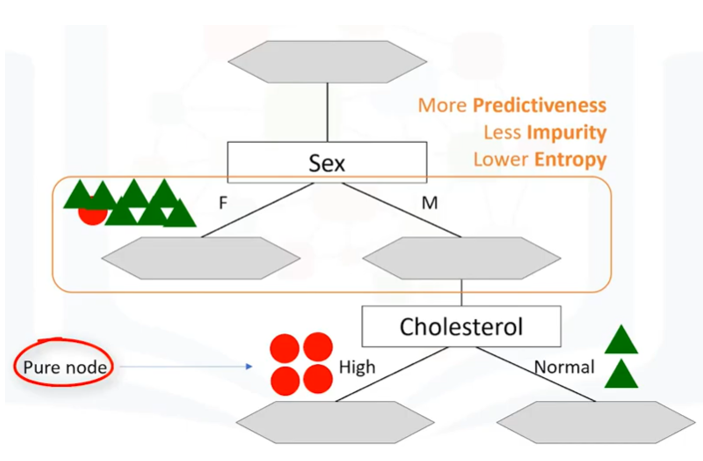

## 🔷 Entropie

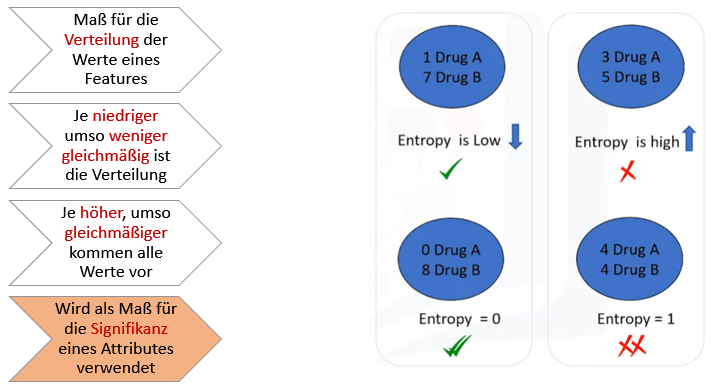

<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Vorhersage der Weinqualität auf Grund von ``proline`` und ``hue``.

---



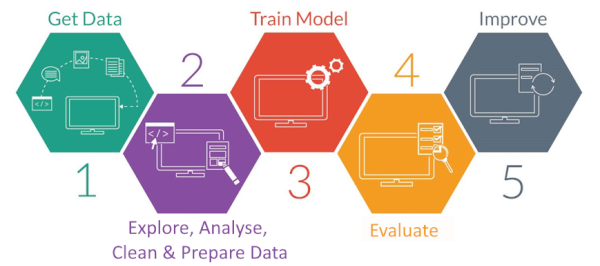

---
# 🟨 ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

Darstellen wie die Klassen verteilt sind

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
plt.figure(figsize=(6, 4))

#------------------------------------------------------------
# Visualisieren der Daten
sns.scatterplot(data=dfWine, x='proline', y='hue', hue='class', palette='Set1')

---
# 🟨 ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Features Skalieren

In [ ]:
#-------------------------------------------------------------
# Führe später die Übung ein weiteres mal mit skalierten Daten durch
# ---> Dein Code 



### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# 🟨 ``Schritt 3:`` Modell erstellen und trainieren


### Modell erstellen und trainieren


Für das Modell verwenden wir diesmal **``DecisionTreeClassifier``** aus dem **Sciki-Learn Paket**.  

> Für dieses Modell gibt es unterschiedlicher Methoden mit denen das Modell trainiert werden kann. <br>  
>
> Dazu zählen:
> ````
>  1. gini
>  2. entropy 
>  3. log_loss
> ````

Welche dieser Methoden sich am Besten für die Daten eignet muss durch Vergleich der Ergebnisse ermittelt werden.  
Für diese Übung verwenden wir als **``criterion="entropy"``** und als Tiefe zur Bestimmung des Informationsgehaltes **``max_depth = 6``**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
model = DecisionTreeClassifier(criterion="entropy", max_depth = 6)
model.fit(train_x,train_y)

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

Visueller Vergleich der tatsächlichen und der vorhergesagten Werte

In [ ]:
# Vergleiche die ersten 5 Werte der Testdaten mit den vorhergesagten Werten
print("Testdaten: ")
print ("Tatsächlich: ", test_y [0:5])
print ("Vorhersagen: ", pred_y [0:5])

In [ ]:
# Grafische Darstellung des Decision Trees
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree

featureNames = dfLearn_X.columns #[0:2]
categories = dfLearn_Y.unique()
fig = plt.figure(figsize=(15,12))
tree.plot_tree(model, 
                   feature_names=featureNames,  
                   class_names=categories,
                   filled=True, fontsize=8);

---
# 🟨 ``Schritt 4:`` Evaluieren


## 🔷 Genauigkeit des Modells

Die Genauigkeit der Vorhersage kann mittels eines **``accuracy_score``** ermittelt werden.

In [ ]:
# Prüfen der Genauigkeit des Models
from sklearn import metrics

print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))


<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit des Modells sagen?<br>
 Begründe deine Antwort!**<br>  
 
89% der Trainingsdaten werden korrekt vorhergesagt. Allerdings nur 75% der Testdaten.

Das kann auf ein Overfitting hindeuten und deshalb sollte das Modell noch weiter untersucht werden.

---
</div>

## 🔷 Visualisieren der Entscheidungsgrenzen


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#------------------------------------------------------------
# Entscheidungsgrenzen des Modells visualisieren
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator( 
            model, train_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[0], cmap = 'brg')

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[1], cmap = 'brg')

#------------------------------------------------------------
# Tatsächliche Werte anzeigen
sns.scatterplot(x=train_x[:,0], y=train_x[:,1], hue=train_y, palette= ['b','r','g'],  ax=axs[0], hue_order=model.classes_)
sns.scatterplot(x=test_x [:,0], y=test_x [:,1], hue=test_y,  palette= ['b','r','g'],  ax=axs[1], hue_order=model.classes_)

plt.show()

---

# 🟨 Praxistest



In [ ]:
# Testdaten generieren
proline = 800
hue  = 0.75
test_data = [[proline, hue]]

# Vorhersage erstellen
wclass = model.predict(test_data)

# Species ausgeben
print("Vorhersage der Klasse: ", wclass[0])

Nun stellt sich noch die Frage, wie hoch ist die Wahrscheinlichkeit das die Vorhersage richtig ist.  
Dazu kann mit ``predict_proba``, die Wahrscheinlichkeit für jede einzelne Kategorie ermittelt werden.

In [ ]:
prob = model.predict_proba( test_data )

print("Wahrscheinlichkeit: ", prob)

for art in range(0,3):
    proz = prob[0,art]*100
    name = model.classes_[art]
    print('%-12s' % name, '%5.1f %%' % proz )

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Vergleiche das Ergebnis mit dem zugehörigen Wert aus den Beobachtungen.**<br>
*Erläutere weiters wie wahrscheinlich das Ergebnis ist.*<br>  



---
</div>

---
# 🟨 ``Schritt 5:`` Improve



### ELLBOW-Methode: ``Finden der besten Genauigkeit``


Bei Decision Trees kann das Modell durch die gewählte Methode und durch die gewählte maximale Tiefe optimiert werden.

Dazu verändern wir hier zum Beispiel die Methode auf ``criterion='gini'`` und prüfen die Genauigkeit bei ``Tiefen von 1 bis 10.``

In [ ]:
import numpy as np

training_accuracy = []
test_accuracy = []

# Bereich festlegen
test_range = range(1, 10)

for depth in test_range:
    
    # Model trainieren 
    model = DecisionTreeClassifier(criterion="gini", max_depth = depth)
    model.fit(train_x,train_y)

    # Trainingsgenauigkeit bestimmen
    pred  = model.predict(train_x)
    score = metrics.accuracy_score(train_y, pred)
    training_accuracy.append(score)

    # Testgenauigkeit bestimmen
    pred  = model.predict(test_x)
    score = metrics.accuracy_score(test_y, pred)
    test_accuracy.append(score)

best_depth = test_range[ np.argmax(test_accuracy) ]
best_score = max(test_accuracy)

# Ausgabe aller Scores 
print( "Höchste TEST-Genauigkeit ist %.3f" % best_score, "mit max_depth=", best_depth) 

#### Verlauf der Genauigkeit
Damit wir die Genauigkeit der verschiedenen Parameter besser vergleichen können, geben wir sie als Graph aus.

In [ ]:
plt.plot(test_range, training_accuracy, label="Trainings-Genauigkeit")
plt.plot(test_range, test_accuracy,     label="Test-Genauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("max_depth")
plt.legend()
#plt.savefig('knn_compare_model')

plt.show()